# MAP-Reduce and Send API with LLM

### What is Map‑Reduce with LLMs?
You use an LLM to:

    MAP → break a big input into smaller chunks
    PROCESS → run the LLM on each chunk in parallel
    REDUCE → merge all LLM outputs into a final answer

This is perfect for:
- Generate specic doc for  a list of subjects
- Summarizing long documents
- Extracting facts from many paragraphs
- Running multiple LLM calls at once
- Multi‑agent fan‑out tasks
- And LangGraph’s Send API makes this easy.

## Problem

Map-reduce operations are essential for efficient task decomposition and parallel processing. 

It has two phases:

(1) `Map` - Break a task into smaller sub-tasks, processing each sub-task in parallel.

(2) `Reduce` - Aggregate the results across all of the completed, parallelized sub-tasks.

## Goal:  Let's design a system that will do two things:

(1) `Map` - Create a set of jokes about a topic using a LLM

(2) `Reduce` - Pick the best joke from the list.

#### NOte: 
- We'll use an LLM to do the job generation and selection.
- Generate structured LLM output usign pydantic model



In [1]:
# Load API key
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GOOGLE_API_USE_V1"] = "true"

# create genai client and llm
from google import genai

client = genai.Client(api_key = os.environ["GOOGLE_API_KEY"])
for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-max-preview-04-2026
models/deep-research-prev

In [54]:
# create a llm using any of the above models
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI( model= "gemini-flash-lite-latest" , 
                              temperature = 0.2 )
llm.invoke("What day is this?").content

[{'type': 'text',
  'text': 'Today is **Tuesday, May 21, 2024**.',
  'extras': {'signature': 'EjQKMgEMOdbHjLXU6XNdueWsuuQ2zGiveRnHAl+aoZFWGoLW42viR6qTDzzEMf3x0K5UatkF'}}]

In [61]:
# define class

from typing import TypedDict , Annotated, List, Literal
from pydantic import BaseModel
from operator import add

# create a blueprint for structured LLM output using pydantic BaseModel
class llm_prompt(BaseModel):
    subjects: List[str]
    id:str
    best_joke : str

# define state
class joke_state(TypedDict):
    topic : str
    subjects: List[str]
    Jokes : Annotated[List[str], add]
    Best_Joke: str

# define node functions
prompt = " Generate a list of 3 sub-topics for a topic: '{topic}' "
def get_subjects(state):
    subject_prompt = prompt.format(topic= state['topic'])
    response  = llm.with_structured_output(llm_prompt).invoke(subject_prompt)
    return {'subjects': response.subjects}

# generate jokes for the subjects
class map_state(TypedDict):
    subject: str
    
def generate_jokes(state: map_state)->joke_state:
    subject = state['subject']
    #print(f"map-subject: {subject}")
    joke_prompt =  f"generate a joke for the subject provided: '{subject}'"
    response = llm.with_structured_output(llm_prompt).invoke(joke_prompt)
    #print(f"response-best joke : {response.best_joke}")
    return { 'Jokes' : [response.best_joke] }

# map-reduce with send API
from langgraph.types import Send

def map_reduce_jokes(state:joke_state):
    subjects = state['subjects']
    return [Send('generate_jokes', {'subject': subj }) for subj in subjects] # list comprehension of map

# get the best joke
def best_joke(state:joke_state):
    jokes = state['Jokes']
    #print(f"jokes list: {jokes}")
    best_joke_prompt = f"For the topic '{state['topic']}', get the best joke out of these jokes: {jokes}"
    response = llm.with_structured_output(llm_prompt).invoke(best_joke_prompt)
    return { 'Best_Joke' : response.best_joke }


#### Here is the magic: we use the Send to create a joke for each subject.

- This is very useful! It can automatically parallelize joke generation for any number of subjects.

**generate_jokes: the name of the node in the graph
{"subject": subj}: the state to send**
- Send allows you to pass any 'state' that you want to generate_jokes! It does not have to align with original state 'joke_state' .

In this case, generate_jokes is using its own internal state, and we can populate this via Send.

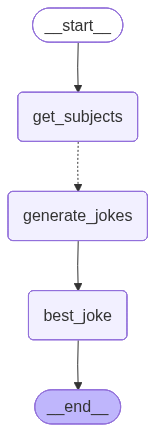

In [62]:
# Build a graph
from langgraph.graph import StateGraph , START , END

builder = StateGraph(joke_state)

# add nodes 
builder.add_node('get_subjects' ,get_subjects)
builder.add_node('generate_jokes' ,generate_jokes)
builder.add_node('best_joke' ,best_joke)

# add edges
builder.add_edge(START , 'get_subjects')
builder.add_conditional_edges('get_subjects' , map_reduce_jokes , ['generate_jokes'])
builder.add_edge('generate_jokes', 'best_joke')
builder.add_edge('best_joke', END)

graph = builder.compile()

from IPython.display import display , Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [71]:
# invoke graph
for chunk in graph.stream({'topic':'Animals'}, stream_mode="values"):
    print(chunk)
    best_joke =chunk
    print("-"*50)

{'topic': 'Animals', 'Jokes': []}
--------------------------------------------------
{'topic': 'Animals', 'subjects': ['Mammals', 'Reptiles', 'Birds'], 'Jokes': []}
--------------------------------------------------
{'topic': 'Animals', 'subjects': ['Mammals', 'Reptiles', 'Birds'], 'Jokes': ['Why do mother kangaroos hate rainy days? Because the kids have to play inside.', 'Why do lizards make such great secret agents? Because they are masters of disguise and always keep their cool.', 'Why do birds fly south for the winter? Because it is too far to walk.']}
--------------------------------------------------
jokes list: ['Why do mother kangaroos hate rainy days? Because the kids have to play inside.', 'Why do lizards make such great secret agents? Because they are masters of disguise and always keep their cool.', 'Why do birds fly south for the winter? Because it is too far to walk.']
{'topic': 'Animals', 'subjects': ['Mammals', 'Reptiles', 'Birds'], 'Jokes': ['Why do mother kangaroos ha

In [72]:
best_joke['Best_Joke']

'Why do mother kangaroos hate rainy days? Because the kids have to play inside.'